# data visualization

## import libraries


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

## pairwise RMSD heatmaps of kunitz domain structures


Processed 'matrix_before.xlsx': found 21 structures (21x21 matrix).


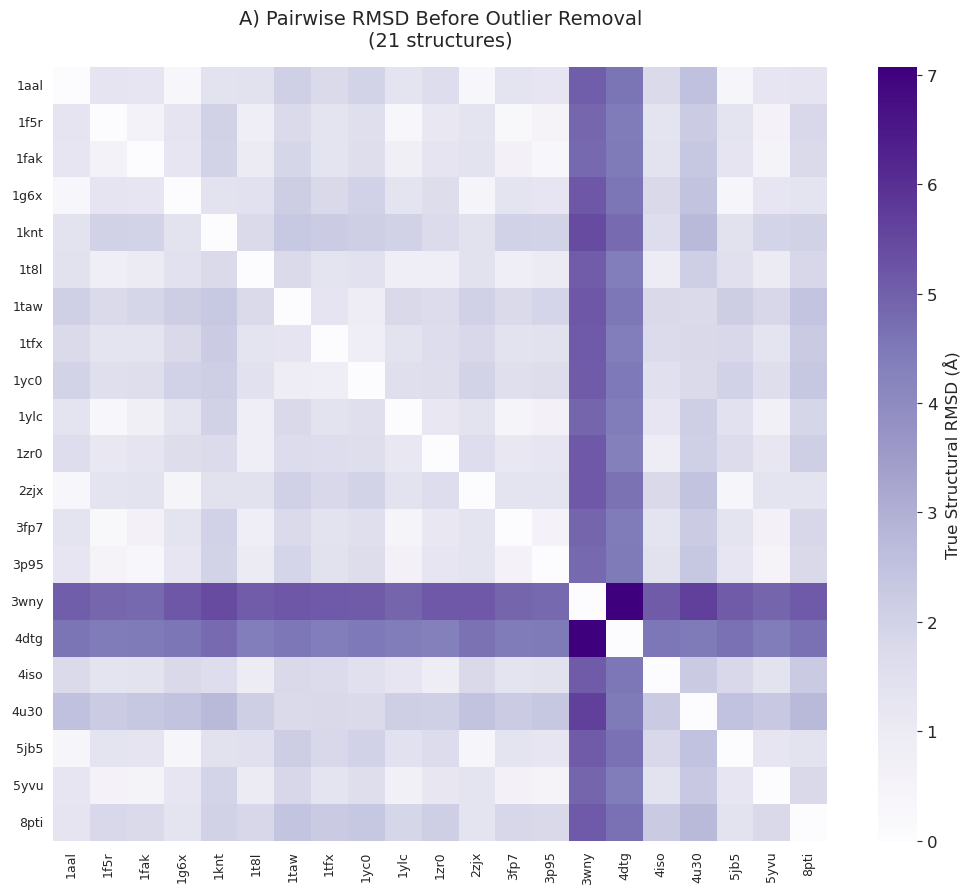

Processed 'matrix_after.xlsx': found 15 structures (15x15 matrix).


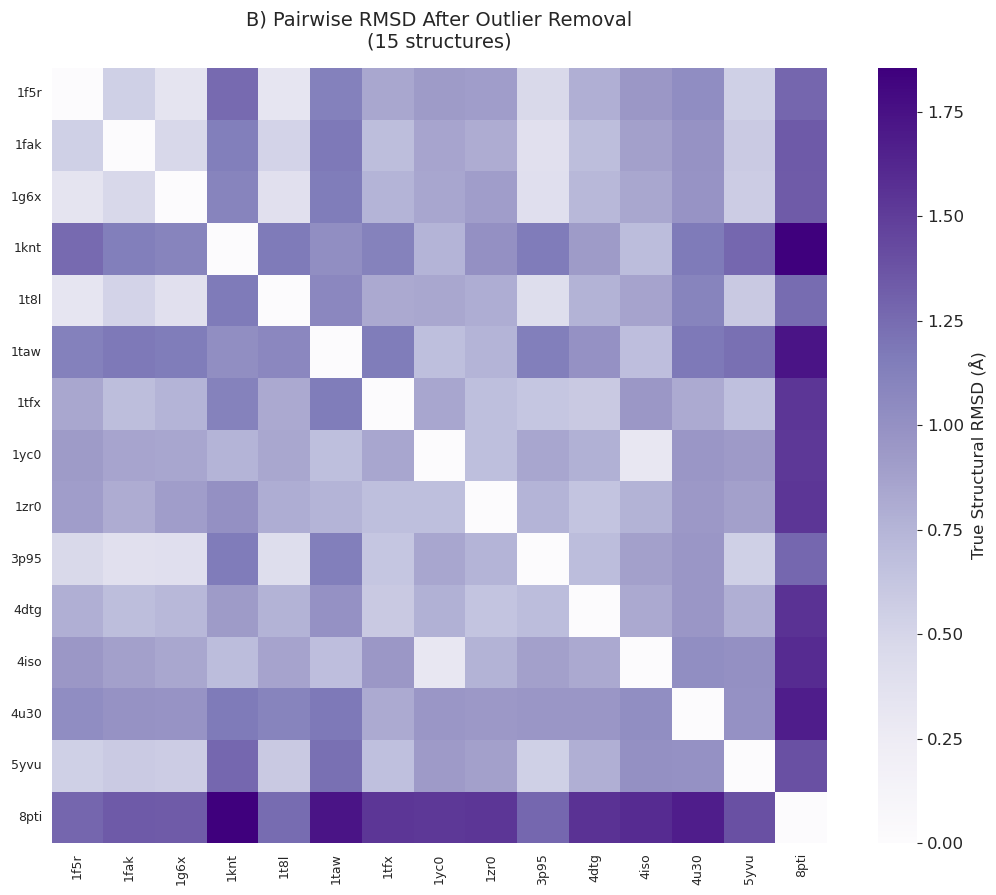


 All figures generated and saved successfully inside the 'figures/' directory!


In [35]:
#setup paths and parameters
output_folder = "figures"
os.makedirs(output_folder, exist_ok=True)
chosen_cmap = "Purples" 

#define a helper dictionary to loop through both files seamlessly
datasets = {
    "before": {
        "file": "matrix_before.xlsx",
        "title_prefix": "A) Pairwise RMSD Before Outlier Removal",
        "save_name": "heatmap_A_before_excel.png"
    },
    "after": {
        "file": "matrix_after.xlsx",
        "title_prefix": "B) Pairwise RMSD After Outlier Removal",
        "save_name": "heatmap_B_after_excel.png"
    }
}

#loop through both datasets to process and plot
for key, info in datasets.items():
    if not os.path.exists(info["file"]):
        print(f"Warning: Could not find '{info['file']}'. Skipping this file.")
        continue
        
    #read the Excel file (Column 0 = rows, Row 0 = columns)
    df = pd.read_excel(info["file"], index_col=0, header=0)
    
    #strip any trailing/leading whitespaces from labels and fill diagonals
    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()
    df = df.fillna(0)
    
    #print out verification shape to monitor progress
    num_structures = df.shape[0]
    print(f"Processed '{info['file']}': found {num_structures} structures ({df.shape[1]}x{df.shape[0]} matrix).")
    
    #generate the heatmap figure
    plt.figure(figsize=(11, 9))
    
    sns.heatmap(
        df, 
        cmap=chosen_cmap, 
        square=True, 
        cbar_kws={'label': 'True Structural RMSD (Å)'}
    )
    
    #format title and ticks
    plt.title(f"{info['title_prefix']}\n({num_structures} structures)", fontsize=14, pad=15)
    plt.xticks(rotation=90, fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    
    # Save image and render plot
    save_path = os.path.join(output_folder, info["save_name"])
    plt.savefig(save_path, dpi=300)
    plt.show()
    
print("\n All figures generated and saved successfully inside the 'figures/' directory!")

## pairwise sequence identity

In [8]:
pip install biopython

  Using cached biopython-1.87-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
Using cached biopython-1.87-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.2 MB)
Note: you may need to restart the kernel to use updated packages.


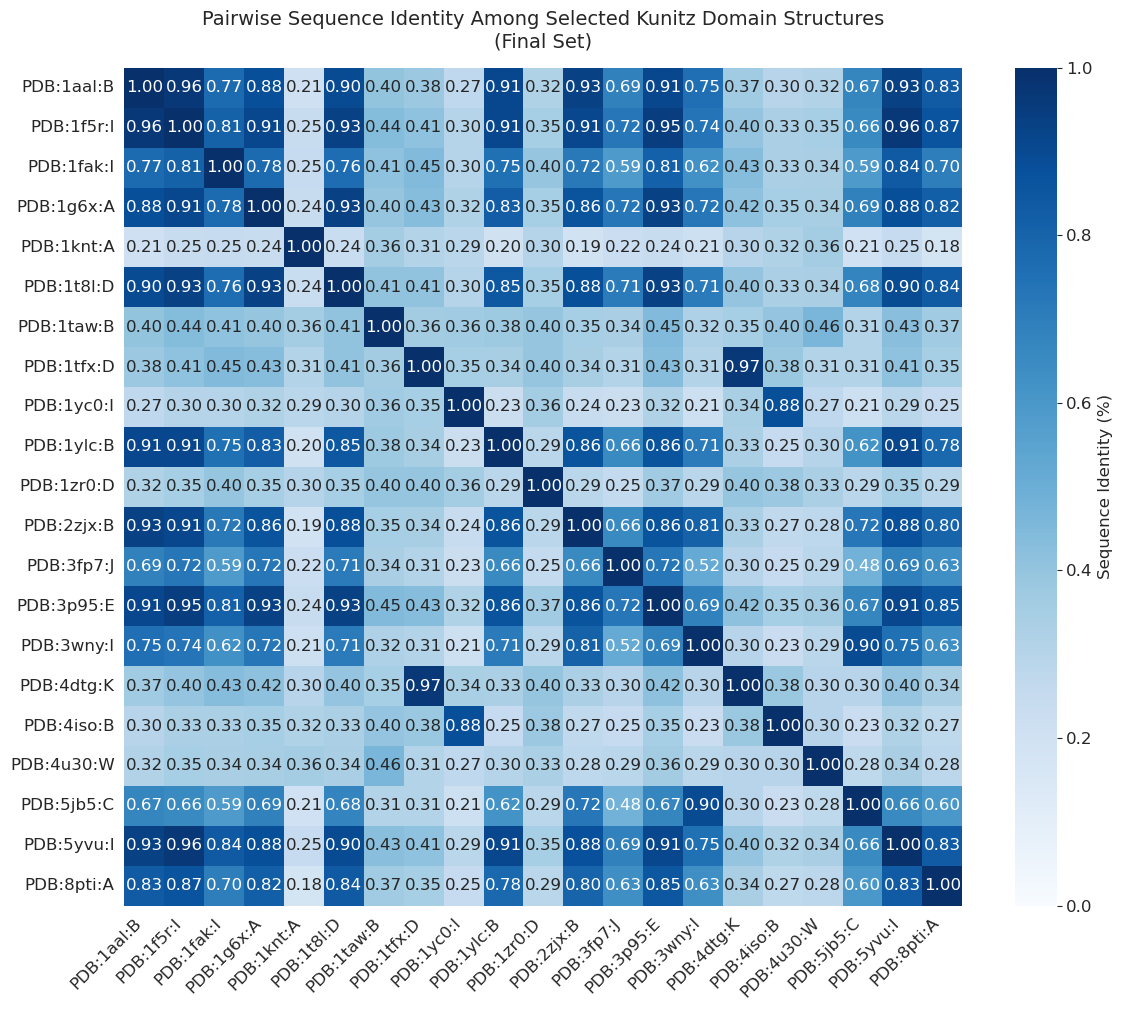

In [9]:
%matplotlib inline
from Bio import AlignIO

alignment_file = "before_alignment.fasta"  
output_folder = "figures"

#load the Multiple Sequence Alignment (MSA)
alignment = AlignIO.read(alignment_file, "fasta")
num_seqs = len(alignment)
seq_ids = [record.id for record in alignment]
seq_len = alignment.get_alignment_length()

#initialize an empty matrix for identity scores
identity_matrix = np.zeros((num_seqs, num_seqs))

#calculate Pairwise Sequence Identity
for i in range(num_seqs):
    for j in range(num_seqs):
        if i == j:
            identity_matrix[i, j] = 1.0  #a sequence compared to itself is 100% identical
        else:
            seq1 = str(alignment[i].seq)
            seq2 = str(alignment[j].seq)
            
            #count matches, ignoring positions where BOTH sequences have a gap
            matches = 0
            valid_positions = 0
            for k in range(seq_len):
                if seq1[k] == '-' and seq2[k] == '-':
                    continue  #skip positions where both are gaps
                
                valid_positions += 1
                if seq1[k] == seq2[k]:
                    matches += 1
            
            #identity = matching positions divided by total compared positions
            identity_matrix[i, j] = matches / valid_positions if valid_positions > 0 else 0.0

#convert to Pandas DataFrame and define the A1 corner label explicitly
df_identity = pd.DataFrame(identity_matrix, index=seq_ids, columns=seq_ids)

#plot the True Sequence Identity Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    df_identity,
    cmap="Blues",      
    annot=True,        
    fmt=".2f",         
    square=True,      
    vmin=0.0,         
    vmax=1.0,        
    cbar_kws={'label': 'Sequence Identity (%)'}
)

plt.title("Pairwise Sequence Identity Among Selected Kunitz Domain Structures\n(Final Set)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

#export high-resolution asset to the figures folder
plt.savefig(os.path.join(output_folder, "sequence_identity_heatmap.png"), dpi=300)
plt.show()

## MCC vs E-value

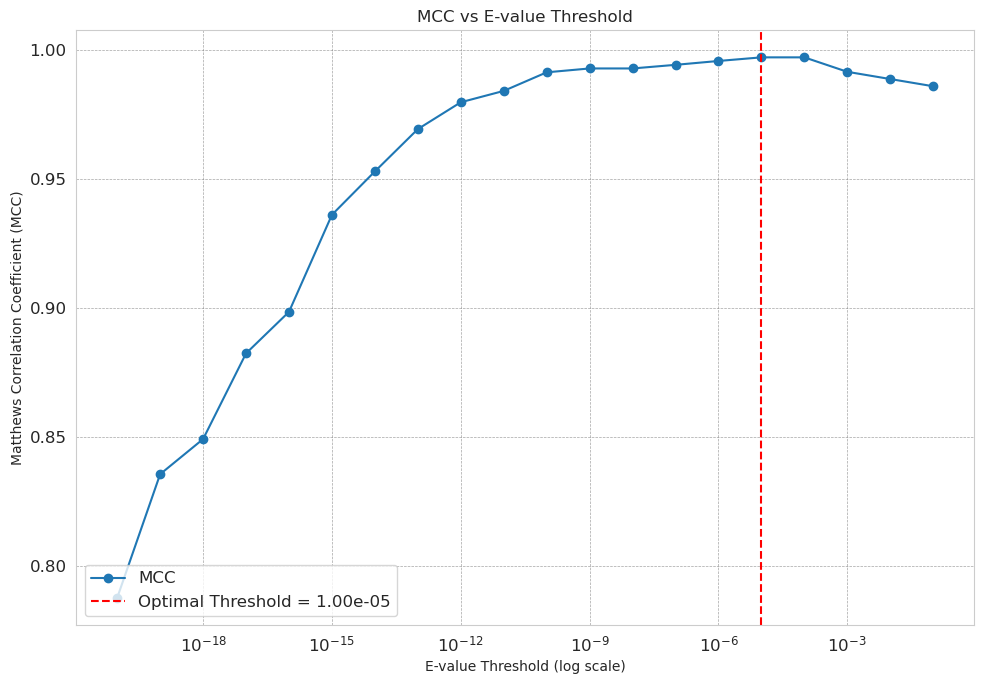

In [11]:
#put your tested E-values here
e_value_thresholds = np.logspace(-20, -1, num=20)

#the exact MCC scores you calculated for each of those thresholds here
mcc_values = [0.7877, 0.8356, 0.8492, 0.8824, 0.8985, 0.9361, 0.9529, 0.9693, 0.9797, 0.9841, 0.9913, 0.9928, 0.9928, 0.9942, 0.9957, 0.9971, 0.9971, 0.9915, 0.9887, 0.9859]

#the specific E-value that gave you your highest MCC score
optimal_threshold = 1.00e-05

#plotting automation
output_folder = "figures"

plt.figure(figsize=(10, 7))

plt.plot(
    e_value_thresholds, 
    mcc_values, 
    marker='o', 
    linestyle='-', 
    color='#1f77b4', 
    label='MCC'
)

#render the optimal line marker
plt.axvline(
    x=optimal_threshold, 
    color='red', 
    linestyle='--', 
    label=f'Optimal Threshold = {optimal_threshold:.2e}'
)

#format to log scale for scientific notation handling
plt.xscale('log')  
plt.grid(True, which="both", linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

#titles & Metadata
plt.title("MCC vs E-value Threshold", fontsize=12)
plt.xlabel("E-value Threshold (log scale)", fontsize=10)
plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=10)
plt.legend(loc='lower left')
plt.tight_layout()

#save into the figures folder
plt.savefig(os.path.join(output_folder, "mcc_vs_threshold.png"), dpi=300)
plt.show()